### `Task` How dimensionality reduction using Principal Component Analysis (PCA) on the Wine Quality dataset contributes to improving the classification accuracy and efficiency of wine type.

Note : Use KNN for Classification.

Data Link :  [Wine Data](https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv)

In [1]:
# Data Loading
import pandas as pd
wine_data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"
wine = pd.read_csv(wine_data_path)
wine.head(5)

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [118]:
wine['type'].value_counts()

,count
type,
white,4870
red,1593


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [20]:
import pandas as pd
wine.dropna(inplace=True)
wine.isnull().sum()

,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


In [122]:
X_train,X_test,y_train,y_test=train_test_split(wine.drop("type",axis=1),wine["type"],test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)



In [123]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
y_train=label_encoder.fit_transform(y_train)
y_test=label_encoder.transform(y_test)

In [23]:
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [24]:
y_pred=knn.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9891724671307038

In [62]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
X_train_pca=pca.fit_transform(X_train)
X_test_pca=pca.transform(X_test)

In [63]:
knn=KNeighborsClassifier()
knn.fit(X_train_pca,y_train)

KNeighborsClassifier()

In [64]:
y_pred1=knn.predict(X_test_pca)

In [61]:
accuracy_score(y_test,y_pred1)

0.9783449342614076

In [38]:
scores=[]
for i in range(1,11):
    pca=PCA(n_components=i)
    X_train_pca=pca.fit_transform(X_train)
    X_test_pca=pca.transform(X_test)

    knn=KNeighborsClassifier()
    knn.fit(X_train_pca,y_train)
    y_pred1=knn.predict(X_test_pca)
    accuracy=accuracy_score(y_test,y_pred1)
    scores.append(accuracy)

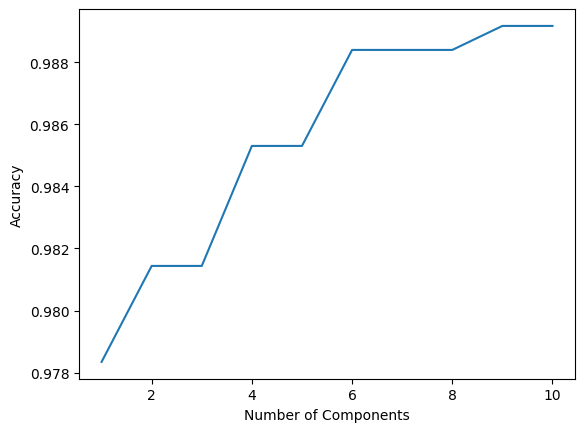

In [41]:
from matplotlib import pyplot as plt
import numpy as np
plt.plot(np.arange(1,11),scores)
plt.xlabel("Number of Components")
plt.ylabel("Accuracy")
plt.show()

In [47]:
# Pca from scratch

KeyError: 'malic_acid'

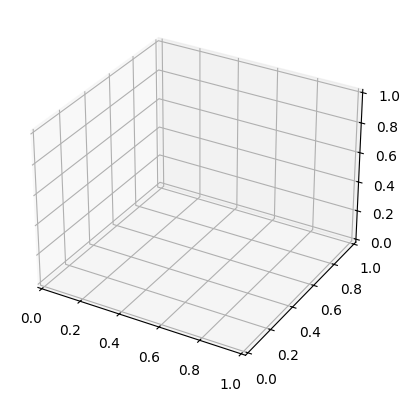

In [76]:
fig=plt.figure()
ax=plt.subplot(projection="3d")
ax.scatter(wine["alcohol"],wine["malic_acid"],wine["ash"])
plt.show()

In [90]:
covariance_matrix = np.cov(X_train, rowvar=False)

In [91]:
covariance_matrix

array([[ 1.00019346,  0.21365446,  0.32107218, -0.11143024,  0.28918021,
        -0.28466351, -0.33598678,  0.4537728 , -0.25355218,  0.30339946,
        -0.09696698, -0.07765613],
       [ 0.21365446,  1.00019346, -0.37894304, -0.20119493,  0.36954966,
        -0.35140254, -0.41917519,  0.26398674,  0.25882245,  0.22472075,
        -0.03237063, -0.26648554],
       [ 0.32107218, -0.37894304,  1.00019346,  0.14036161,  0.03593718,
         0.12490777,  0.19201718,  0.09523275, -0.32277044,  0.06748548,
        -0.01052709,  0.08266299],
       [-0.11143024, -0.20119493,  0.14036161,  1.00019346, -0.13090585,
         0.40090273,  0.4907007 ,  0.5598907 , -0.27325513, -0.19049833,
        -0.35992867, -0.02554623],
       [ 0.28918021,  0.36954966,  0.03593718, -0.13090585,  1.00019346,
        -0.1961972 , -0.27923374,  0.34845389,  0.04225   ,  0.41317787,
        -0.24794723, -0.19529994],
       [-0.28466351, -0.35140254,  0.12490777,  0.40090273, -0.1961972 ,
         1.00019346,  

In [92]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [93]:
eigen_values

array([3.03863301, 2.62435106, 1.63495697, 1.08280615, 0.03335259,
       0.85471658, 0.22836836, 0.30445692, 0.66769402, 0.56614821,
       0.46208847, 0.50474919])

In [94]:
eigen_vectors

array([[ 2.56782402e-01,  2.67990206e-01, -4.60127388e-01,
        -1.50816988e-01, -3.30432776e-01,  1.65950132e-01,
         2.82419493e-01, -2.78402692e-01, -4.40658068e-02,
        -3.99300599e-01,  4.05024757e-01, -9.14284370e-02],
       [ 3.93716674e-01,  1.01451970e-01,  2.89381533e-01,
        -7.90388268e-02, -8.69667914e-02,  1.45471514e-01,
        -1.30586260e-01,  4.98910194e-01,  3.46672902e-01,
        -4.77211425e-01, -7.67096482e-02,  3.10192389e-01],
       [-1.42705246e-01,  1.47352492e-01, -5.88248241e-01,
         5.78991759e-02, -6.67295751e-04, -2.35013034e-01,
        -2.30158033e-01,  3.29410618e-01, -3.73483158e-01,
        -5.49686183e-02, -1.59067967e-01,  4.73291310e-01],
       [-3.22901972e-01,  3.44316561e-01,  7.82154960e-02,
         8.76071809e-02, -4.59985998e-01,  4.92678588e-01,
         3.39398231e-06, -1.99225620e-01,  6.20745275e-02,
         9.37576901e-02, -4.79668834e-01,  1.63253303e-01],
       [ 3.12551683e-01,  2.68119444e-01, -4.1041954

In [105]:
pc = eigen_vectors[0:3]
pc

array([[ 0.2567824 ,  0.26799021, -0.46012739, -0.15081699, -0.33043278,
         0.16595013,  0.28241949, -0.27840269, -0.04406581, -0.3993006 ,
         0.40502476, -0.09142844],
       [ 0.39371667,  0.10145197,  0.28938153, -0.07903883, -0.08696679,
         0.14547151, -0.13058626,  0.49891019,  0.3466729 , -0.47721142,
        -0.07670965,  0.31019239],
       [-0.14270525,  0.14735249, -0.58824824,  0.05789918, -0.0006673 ,
        -0.23501303, -0.23015803,  0.32941062, -0.37348316, -0.05496862,
        -0.15906797,  0.47329131]])

In [106]:
transformed_df = np.dot(X_train,pc.T)
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2','PC3'])
new_df['target'] = y_train
new_df.head()

,PC1,PC2,PC3,target
0,0.075990,0.490933,-1.377097,1
1,-0.047347,1.308295,-2.532259,1
2,-0.463259,-0.652303,-1.244507,1
3,1.329028,-0.403018,-0.100641,1
4,1.928212,-0.867023,0.144860,1


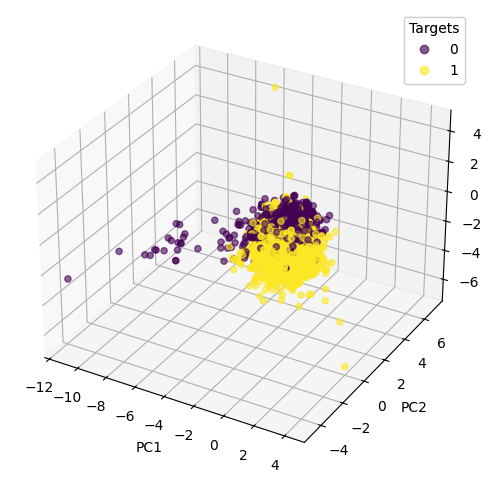

In [113]:
fig=plt.figure(figsize=(8, 6))
ax=plt.subplot(projection="3d")
scatter=ax.scatter(new_df["PC1"],new_df["PC2"],new_df["PC3"],c=new_df["target"],
    cmap="viridis",
    alpha=0.6)


ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

# 3. Add a legend to show what the colors mean
legend = ax.legend(*scatter.legend_elements(), title="Targets")
ax.add_artist(legend)

plt.show()

In [120]:
import plotly.express as px

fig = px.scatter_3d(
    new_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="target",  # Directly uses 'white' and 'red' strings
    color_discrete_map={"white": "gold", "red": "crimson"},
    title="PCA of Wine Dataset",
    opacity=0.6
)
fig.show()

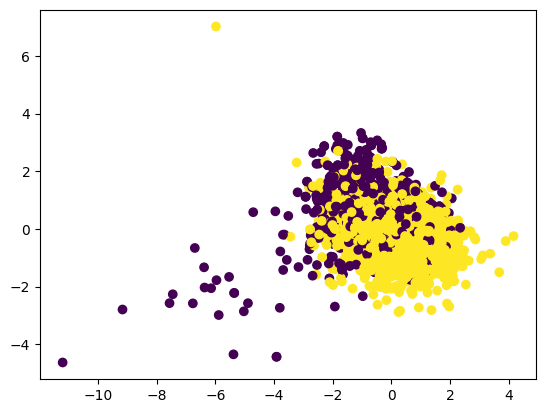

In [115]:
plt.scatter(new_df["PC1"],new_df["PC2"],c=new_df["target"])

In [126]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Scale your features (Essential step before running PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# 2. Fit PCA and transform to 3 components directly
pca = PCA(n_components=3)
transformed_data = pca.fit_transform(X_scaled)

# 3. Rebuild your DataFrame cleanly
new_df = pd.DataFrame(transformed_data, columns=['PC1', 'PC2', 'PC3'])
new_df['target'] = y_train

# Check the results
print(new_df.head(10))

        PC1       PC2       PC3  target
0  2.433836  2.114089 -2.127539       1
1  0.716105 -0.967821  2.634449       1
2  1.878257  0.308748 -0.566533       1
3  0.738302 -1.342336 -0.753433       1
4  1.379624 -2.301495  0.730025       1
5  0.829929 -2.754468  0.949015       1
6  1.392337 -0.404218  0.120616       1
7  0.925950 -2.256738 -0.695534       1
8 -0.198731 -1.761711 -0.083785       1
9 -2.276699  0.184365  1.290227       0
